<a href="https://colab.research.google.com/github/nurcankurt/speculative_decoding_analysis/blob/main/speculative_decoding_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Environment Setup & Libraries
!pip install -q transformers torch pandas datasets matplotlib seaborn

import time
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check execution environment
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Execution Environment: {device.upper()}")

Execution Environment: CPU


In [ ]:
# Loading Target and Draft Models
print("Loading Target and Draft Models...")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Target Model: GPT-2 (117M parameters)
target_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)

# Draft Models Dictionary
draft_models = {
    "DistilGPT-2 (82M)": AutoModelForCausalLM.from_pretrained("distilgpt2").to(device),
    "Tiny-GPT2 (15M)": AutoModelForCausalLM.from_pretrained("sshleifer/tiny-gpt2").to(device)
}
print("Models loaded successfully.")

Loading Target and Draft Models...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0, 1}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded successfully.


In [ ]:
# Dataset Loading & Prompt Selection
print("Downloading WikiText-103 test split...")
wiki_dataset = load_dataset("wikitext", "wikitext-103-v1", split="test")

# Filter empty lines and get a sensible prompt
valid_texts = [text for text in wiki_dataset['text'] if len(text.split()) > 20]
sample_text = valid_texts[5]
prompt = " ".join(sample_text.split()[:12])
print(f"Selected Prompt from WikiText-103: '{prompt}...'")

README.md: 0.00B [00:00, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Selected Prompt from WikiText-103: 'Boulter starred in two films in 2008 , Daylight Robbery by filmmaker...'


In [ ]:
#  Core Algorithm (Rejection Sampling & Perplexity)
def sample_from_distribution(logits, temperature=1.0):
    if temperature == 0.0: return torch.argmax(logits, dim=-1)
    scaled_logits = logits / temperature
    probs = F.softmax(scaled_logits, dim=-1)
    return torch.multinomial(probs, 1)[0]

def get_probs_from_logits(logits, temperature=1.0):
    if temperature == 0.0:
        idx = torch.argmax(logits, dim=-1)
        probs = torch.zeros_like(logits)
        probs[idx] = 1.0
        return probs
    return F.softmax(logits / temperature, dim=-1)

def calculate_perplexity(model, input_ids):
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss
        perplexity = torch.exp(loss)
    return perplexity.item()

def speculative_decoding_step(generated_ids, target_model, draft_model, gamma=4, temperature=0.0):
    step_drafted_ids = generated_ids.clone()
    draft_probs_list = []

    # PHASE 1: DRAFTING
    with torch.no_grad():
        for _ in range(gamma):
            outputs = draft_model(step_drafted_ids)
            next_token_logits = outputs.logits[0, -1, :]
            probs = get_probs_from_logits(next_token_logits, temperature)
            next_token = sample_from_distribution(next_token_logits, temperature).unsqueeze(0).unsqueeze(0)
            step_drafted_ids = torch.cat([step_drafted_ids, next_token], dim=-1)
            draft_probs_list.append(probs)

    drafted_tokens = step_drafted_ids[0, generated_ids.shape[1]:]

    # PHASE 2: VERIFICATION
    with torch.no_grad():
        target_outputs = target_model(step_drafted_ids)
        start_idx = generated_ids.shape[1] - 1
        end_idx = start_idx + gamma + 1
        target_logits = target_outputs.logits[0, start_idx:end_idx, :]

    # PHASE 3: ACCEPTANCE
    n = gamma
    for i in range(gamma):
        token_id = drafted_tokens[i].item()
        p_dist = get_probs_from_logits(target_logits[i], temperature)
        q_dist = draft_probs_list[i]

        p_val = p_dist[token_id].item()
        q_val = q_dist[token_id].item()

        r = torch.rand(1).item()
        if r > (p_val / (q_val + 1e-9)):
            n = i
            break

    # PHASE 4: CORRECTION
    if n < gamma:
        p_dist = get_probs_from_logits(target_logits[n], temperature)
        q_dist = draft_probs_list[n]
        if temperature == 0.0:
            t = torch.argmax(target_logits[n]).unsqueeze(0).unsqueeze(0)
        else:
            adjusted_probs = torch.clamp(p_dist - q_dist, min=0.0)
            adjusted_probs = adjusted_probs / (adjusted_probs.sum() + 1e-9)
            if adjusted_probs.sum() == 0: adjusted_probs = p_dist
            t = sample_from_distribution(torch.log(adjusted_probs + 1e-9), temperature=1.0).unsqueeze(0).unsqueeze(0)
    else:
        if temperature == 0.0: t = torch.argmax(target_logits[n]).unsqueeze(0).unsqueeze(0)
        else: t = sample_from_distribution(target_logits[n], temperature).unsqueeze(0).unsqueeze(0)

    accepted_prefix = drafted_tokens[:n].unsqueeze(0) if n > 0 else torch.empty((1, 0), dtype=torch.long, device=device)
    new_tokens = torch.cat([accepted_prefix, t], dim=-1)
    return torch.cat([generated_ids, new_tokens], dim=-1), n

In [ ]:
# Evaluation Engine
def evaluate_baseline(input_text, target_model, tokenizer, max_length=60, temp=0.0):
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

    if device == "cuda": torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        output_ids = target_model.generate(
            input_ids, max_new_tokens=max_length - input_ids.shape[1],
            do_sample=(temp > 0.0), temperature=temp if temp > 0.0 else None
        )

    if device == "cuda": torch.cuda.synchronize()
    latency = time.time() - start_time
    gen_tokens = output_ids.shape[1] - input_ids.shape[1]
    ppl = calculate_perplexity(target_model, output_ids)

    return {
        "Model": "Baseline",
        "K": 0,
        "Latency (s)": round(latency, 3),
        "Tokens/Sec": round(gen_tokens / latency, 2),
        "Acceptance Rate (%)": None,
        "Perplexity": round(ppl, 2)
    }

def evaluate_speculative(input_text, target_model, draft_model, model_name, tokenizer, k_gamma, max_length=60, temp=0.0):
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    generated_ids = input_ids.clone()

    total_accepted = 0
    drafted_total = 0

    if device == "cuda": torch.cuda.synchronize()
    start_time = time.time()

    while generated_ids.shape[1] < max_length:
        drafted_total += k_gamma
        generated_ids, accepted_count = speculative_decoding_step(
            generated_ids, target_model, draft_model, gamma=k_gamma, temperature=temp
        )
        total_accepted += accepted_count
        if generated_ids[0, -1].item() == tokenizer.eos_token_id: break

    if device == "cuda": torch.cuda.synchronize()
    latency = time.time() - start_time
    gen_tokens = generated_ids.shape[1] - input_ids.shape[1]

    acc_rate = (total_accepted / drafted_total) * 100 if drafted_total > 0 else 0
    ppl = calculate_perplexity(target_model, generated_ids)

    return {
        "Model": model_name,
        "K": k_gamma,
        "Latency (s)": round(latency, 3),
        "Tokens/Sec": round(gen_tokens / latency, 2),
        "Acceptance Rate (%)": round(acc_rate, 1),
        "Perplexity": round(ppl, 2)
    }

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


----------------------------------------------------------------------
RUNNING BENCHMARK: Multiple Models, K=1 to 8
----------------------------------------------------------------------


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Testing DistilGPT-2 (82M)...
Testing Tiny-GPT2 (15M)...

--- EXPERIMENT DATA ---
            Model  K  Latency (s)  Tokens/Sec  Acceptance Rate (%)  Perplexity
         Baseline  0        8.622        7.54                  NaN        6.23
DistilGPT-2 (82M)  1       17.928        3.68                 57.1        6.09
DistilGPT-2 (82M)  2       18.770        3.52                 53.1        6.09
DistilGPT-2 (82M)  3       23.978        2.84                 42.2        5.87
DistilGPT-2 (82M)  4       26.604        2.44                 37.5        6.23
DistilGPT-2 (82M)  5       33.685        1.96                 30.8        6.09
DistilGPT-2 (82M)  6       28.503        2.35                 29.9        5.99
DistilGPT-2 (82M)  7       32.811        2.07                 26.2        5.87
DistilGPT-2 (82M)  8       36.750        1.88                 23.4        5.82
  Tiny-GPT2 (15M)  1       17.121        3.80                  0.0        6.23
  Tiny-GPT2 (15M)  2       17.578        3.70     

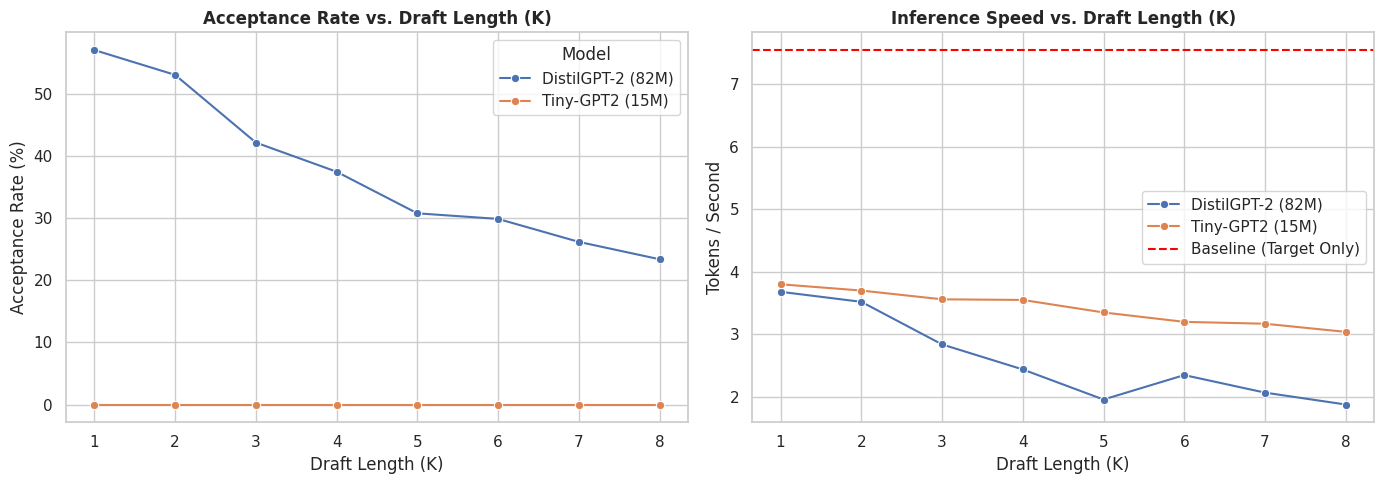

In [ ]:
# Experiment Execution & Visualization
print("-" * 70)
print("RUNNING BENCHMARK: Multiple Models, K=1 to 8")
print("-" * 70)

results = []
TEST_TEMP = 0.0
MAX_SEQ_LEN = 80

# Run Baseline Model
results.append(evaluate_baseline(prompt, target_model, tokenizer, max_length=MAX_SEQ_LEN, temp=TEST_TEMP))

# Run Speculative Models
for draft_name, draft_model_instance in draft_models.items():
    print(f"Testing {draft_name}...")
    for k in range(1, 9):
        res = evaluate_speculative(prompt, target_model, draft_model_instance, draft_name, tokenizer, k_gamma=k, max_length=MAX_SEQ_LEN, temp=TEST_TEMP)
        results.append(res)

# Display Text Results
df_results = pd.DataFrame(results)
print("\n--- EXPERIMENT DATA ---")
print(df_results.to_string(index=False))

# Plotting Data (Matplotlib & Seaborn)
sns.set_theme(style="whitegrid")
df_spec = df_results[df_results["Model"] != "Baseline"]
baseline_tps = df_results[df_results["Model"] == "Baseline"]["Tokens/Sec"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Acceptance Rate vs. K
sns.lineplot(data=df_spec, x="K", y="Acceptance Rate (%)", hue="Model", marker="o", ax=axes[0])
axes[0].set_title("Acceptance Rate vs. Draft Length (K)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Acceptance Rate (%)")
axes[0].set_xlabel("Draft Length (K)")

# Plot 2: Tokens/Sec vs. K
sns.lineplot(data=df_spec, x="K", y="Tokens/Sec", hue="Model", marker="o", ax=axes[1])
axes[1].axhline(baseline_tps, ls="--", color="red", label="Baseline (Target Only)")
axes[1].set_title("Inference Speed vs. Draft Length (K)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Tokens / Second")
axes[1].set_xlabel("Draft Length (K)")
axes[1].legend()

plt.tight_layout()
plt.show()